In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="pandas")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="matplotlib")

In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s5e4/train.csv")
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [3]:
df.isna().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [4]:
df.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [6]:
df = df.drop(columns=["id"])

## Analysis of Numeric Features
The goal of this section is to understand the nature of the numerical features as well as how they relate to one another. This will be useful for feature engineering and feature selection.

In [7]:
num_vars = ["Episode_Length_minutes", "Host_Popularity_percentage", "Guest_Popularity_percentage", 
                "Number_of_Ads", "Listening_Time_minutes"]

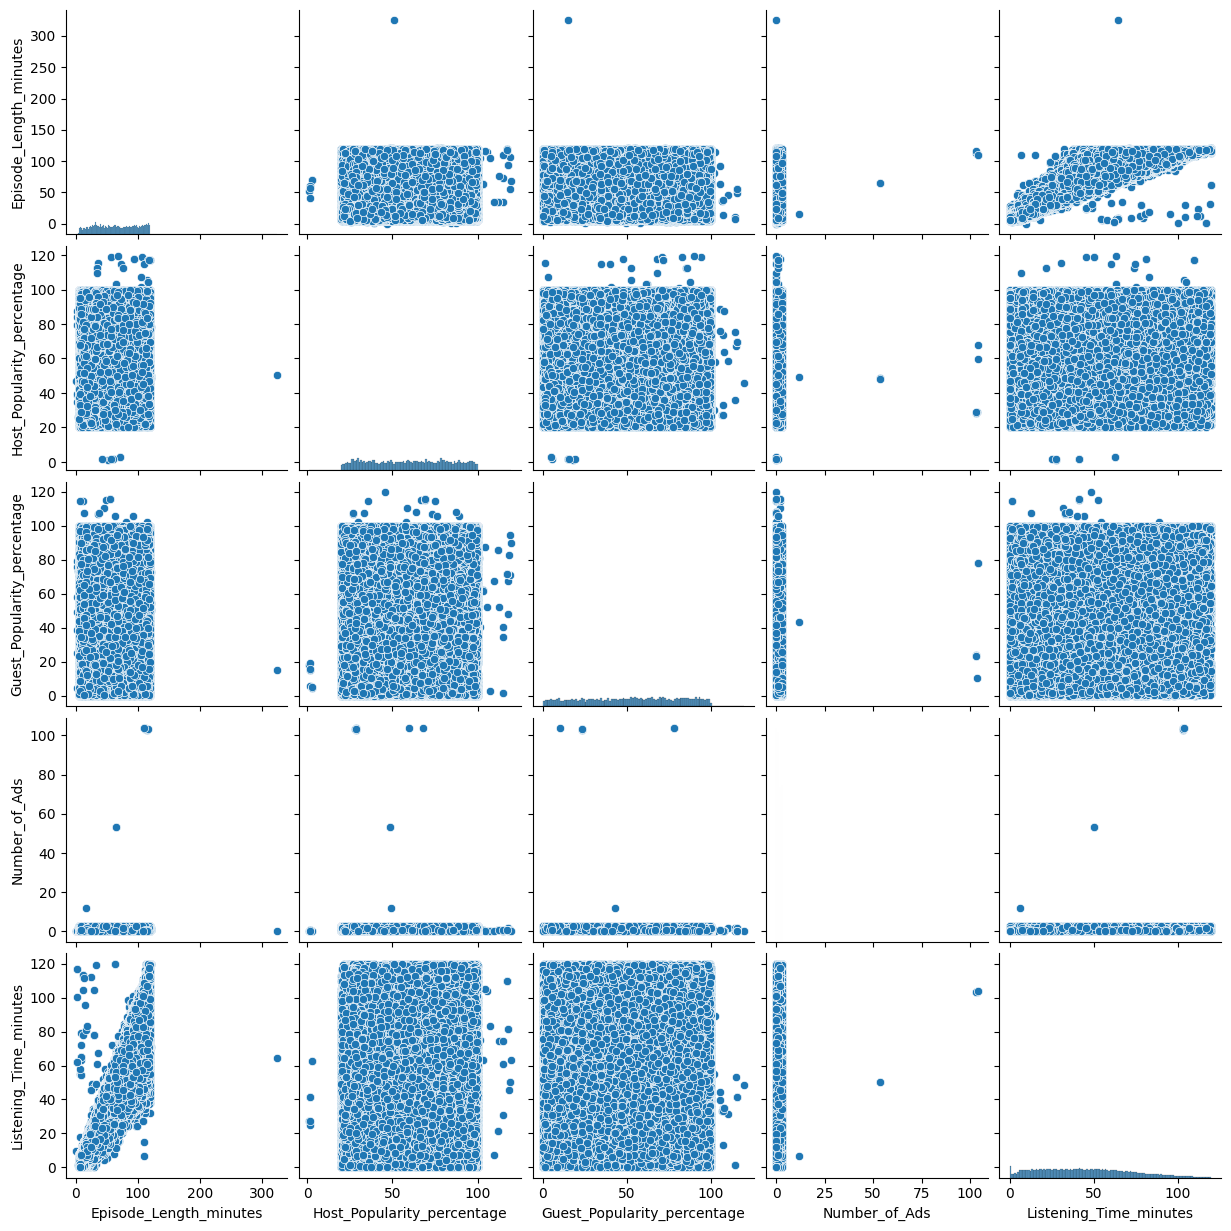

In [8]:
# pairplot
sns.pairplot(df[num_vars])

In [9]:
# dropping outliers to prevent future visualizations from messing up
df = df[((df["Number_of_Ads"] < 10) | df["Number_of_Ads"].isna()) & 
             ((df["Episode_Length_minutes"] < 300) | df["Episode_Length_minutes"].isna()) & 
             (df["Host_Popularity_percentage"] <= 100) &
             (df["Host_Popularity_percentage"] >= 20) &
             ((df["Guest_Popularity_percentage"] <= 100) | df["Guest_Popularity_percentage"].isna())]

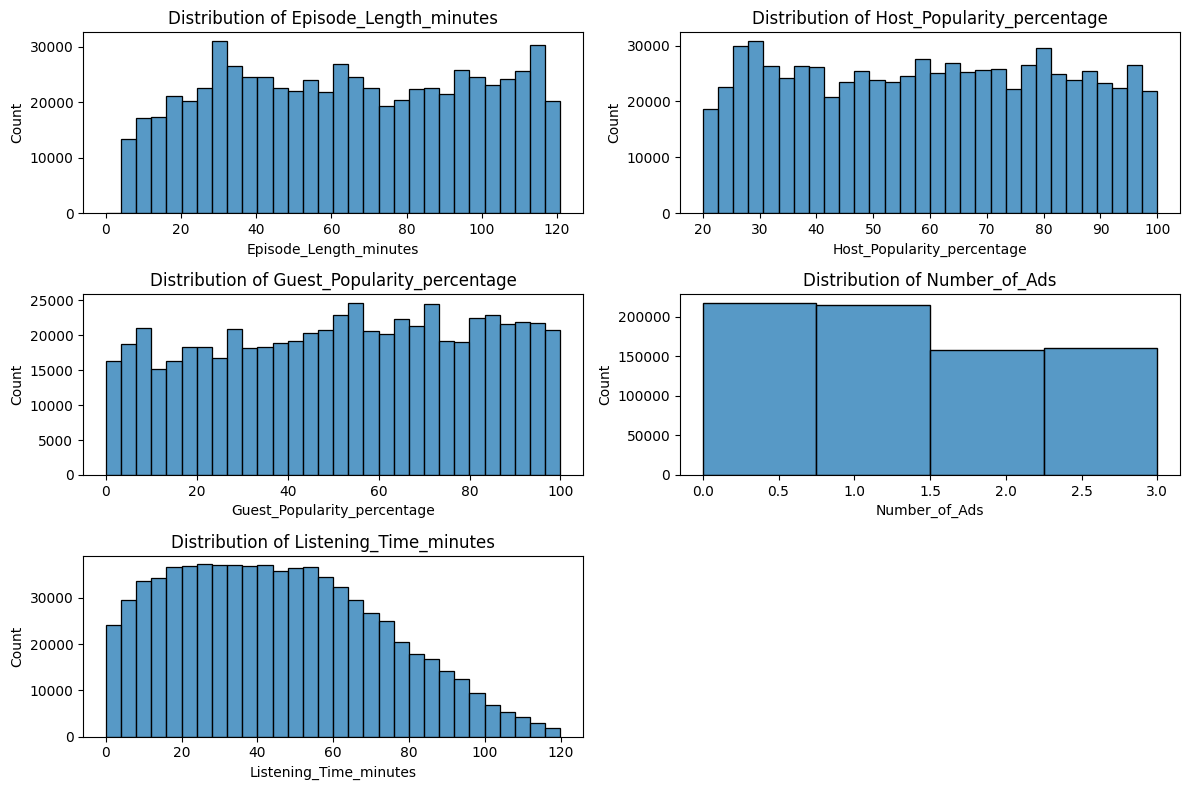

In [10]:
# histograms
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.histplot(df[feature], ax=axes[i], bins=min(df[feature].nunique(), 30))
    axes[i].set_title(f"Distribution of {feature}")

axes[5].remove()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

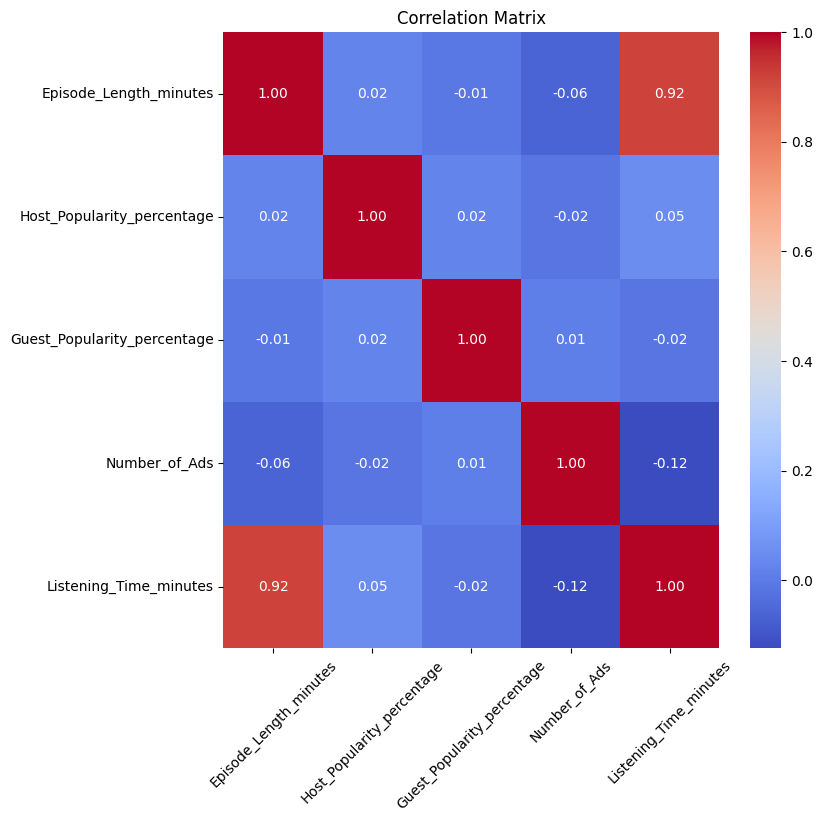

In [11]:
# correlation Matrix
corr_matrix = df[num_vars].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.title("Correlation Matrix")

### Findings from looking at distributions of numeric data  
Data Cleaning
- Need to figure out what to do with outliers
- Need to normalize a lot of the data
- investigate more in detail how each feature relates to the outcome
  
Relationships
- Episode Length very strongly correlated with Listening Time
- Nothing else really relates to listening time potentially because of large amounts of missing values?

## Analysis of Categorical Features

In [12]:
cat_vars = ["Podcast_Name", "Episode_Title", "Genre", "Publication_Day",
               "Publication_Time", "Episode_Sentiment"]

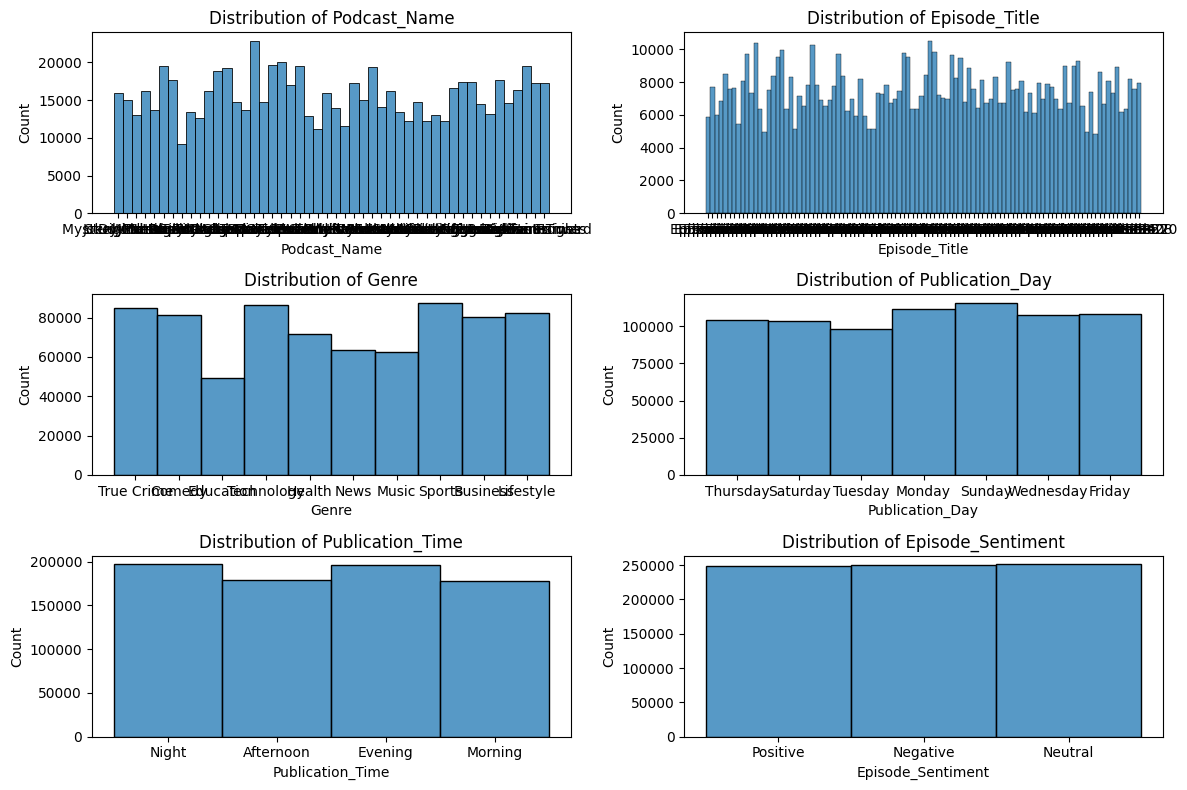

In [13]:
# distributions of categorical features
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.histplot(df[feature], ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

In [14]:
df[cat_vars].nunique()

Podcast_Name          48
Episode_Title        100
Genre                 10
Publication_Day        7
Publication_Time       4
Episode_Sentiment      3
dtype: int64

In [15]:
top_values = {}

for feature in cat_vars:
    top_values[feature] = df[feature].value_counts().head(10).index.tolist()

# Print results
for feature, val in top_values.items():
    print(f"Top values in '{feature}': {val}")

Top values in 'Podcast_Name': ['Tech Talks', 'Sports Weekly', 'Funny Folks', 'Tech Trends', 'Fitness First', 'Business Insights', 'Style Guide', 'Game Day', 'Melody Mix', 'Criminal Minds']
Top values in 'Episode_Title': ['Episode 71', 'Episode 62', 'Episode 31', 'Episode 61', 'Episode 69', 'Episode 23', 'Episode 63', 'Episode 81', 'Episode 64', 'Episode 72']
Top values in 'Genre': ['Sports', 'Technology', 'True Crime', 'Lifestyle', 'Comedy', 'Business', 'Health', 'News', 'Music', 'Education']
Top values in 'Publication_Day': ['Sunday', 'Monday', 'Friday', 'Wednesday', 'Thursday', 'Saturday', 'Tuesday']
Top values in 'Publication_Time': ['Night', 'Evening', 'Afternoon', 'Morning']
Top values in 'Episode_Sentiment': ['Neutral', 'Negative', 'Positive']


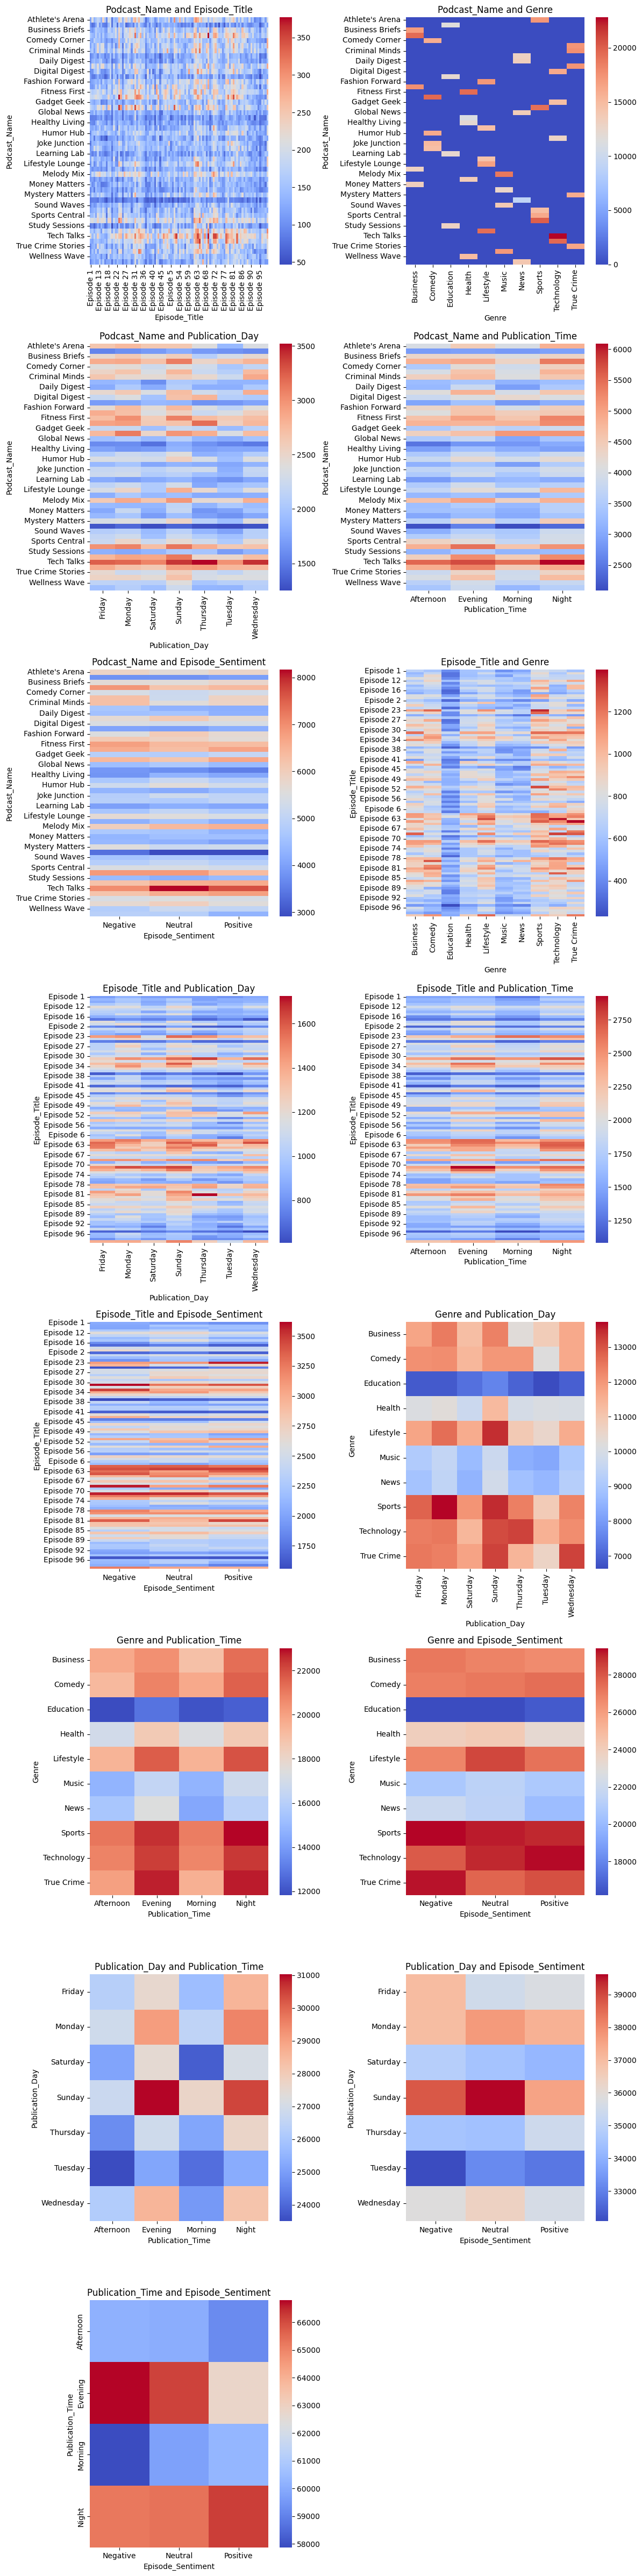

In [16]:
# relationship between categorical features
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        contingency_table = pd.crosstab(df[feature_1], df[feature_2])
        sns.heatmap(contingency_table, cmap="coolwarm", ax=axes[index])
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

### Findings from Categorical Data
For most categories, the distribution is fairly balanced. This is really helpful as it makes model more robust due to the high variation in categories.

- THere are a total of 48 different podcasts in this dataset (at least in this split)
- There are at least 100 different episodes

## Relationships Between Categorical and Numeric Features

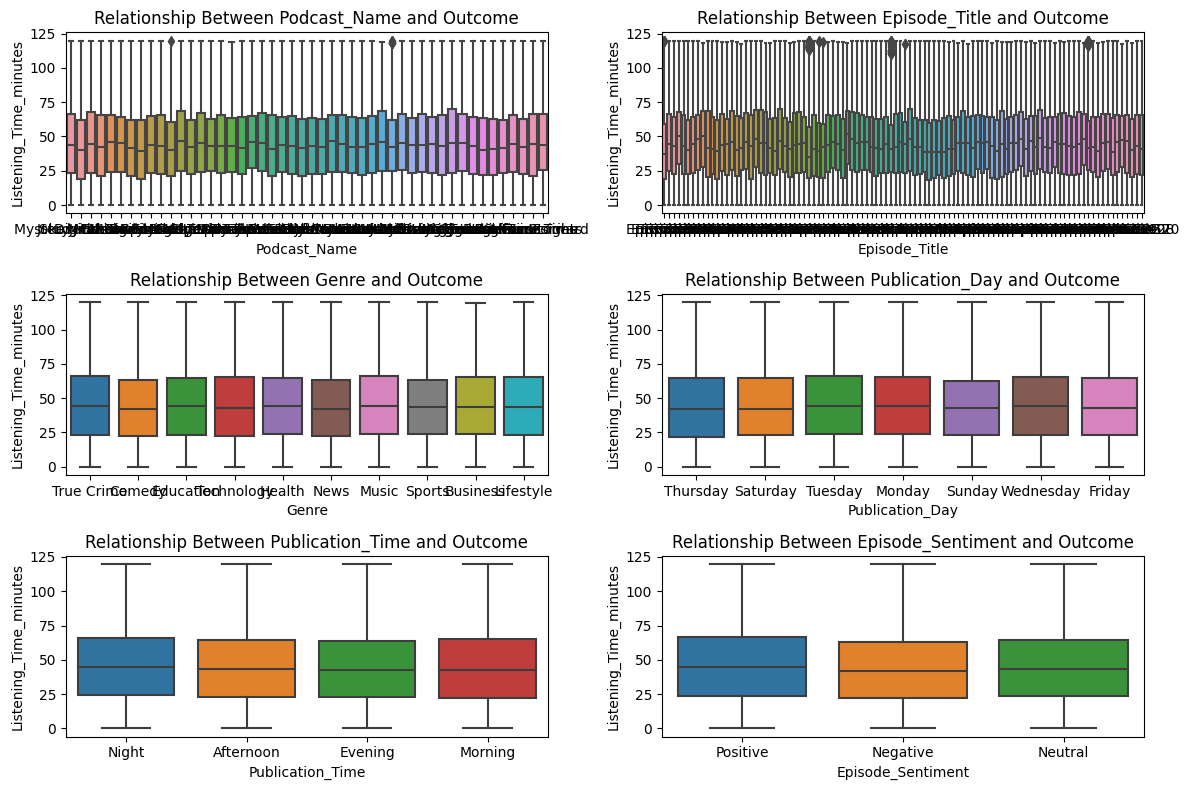

In [17]:
# relationship between cateogircal features and outcome feature
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Listening_Time_minutes"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Outcome")

plt.tight_layout()
plt.show()

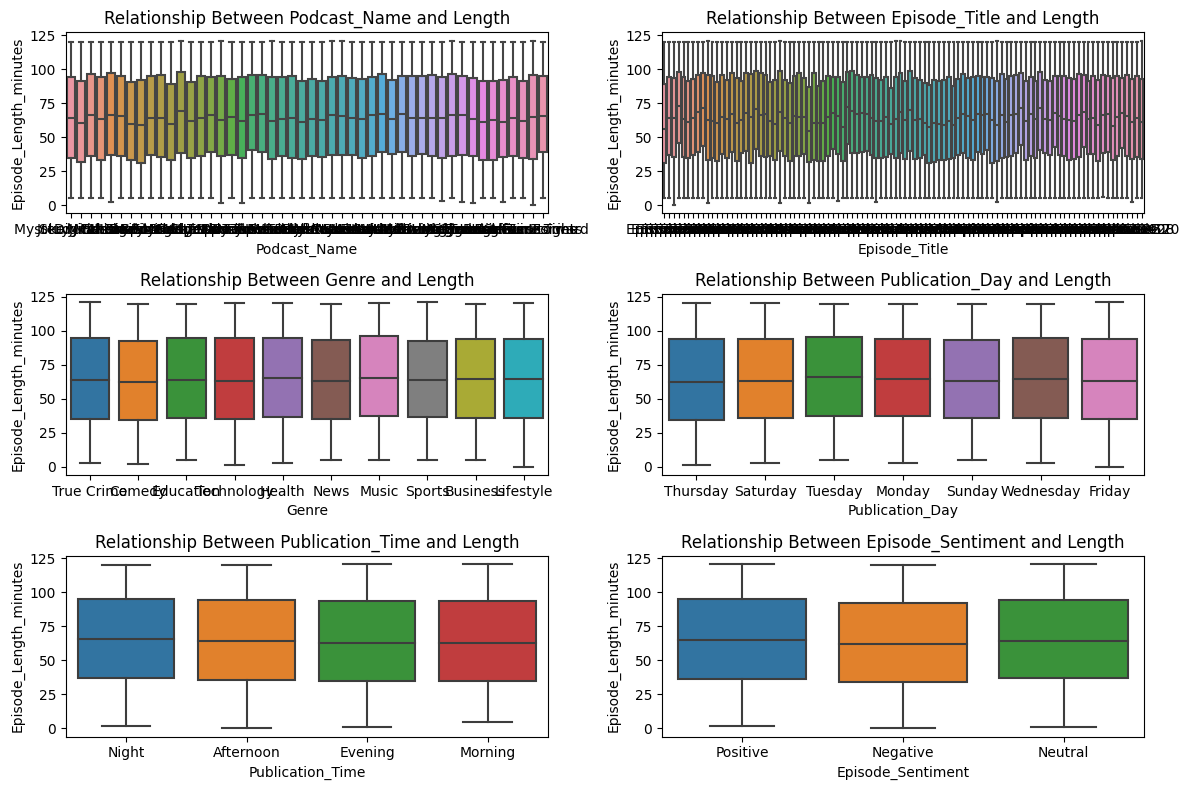

In [18]:
# relationship between cateogircal features and episode length
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df[df["Episode_Length_minutes"] < 300]["Episode_Length_minutes"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Length")

plt.tight_layout()
plt.show()

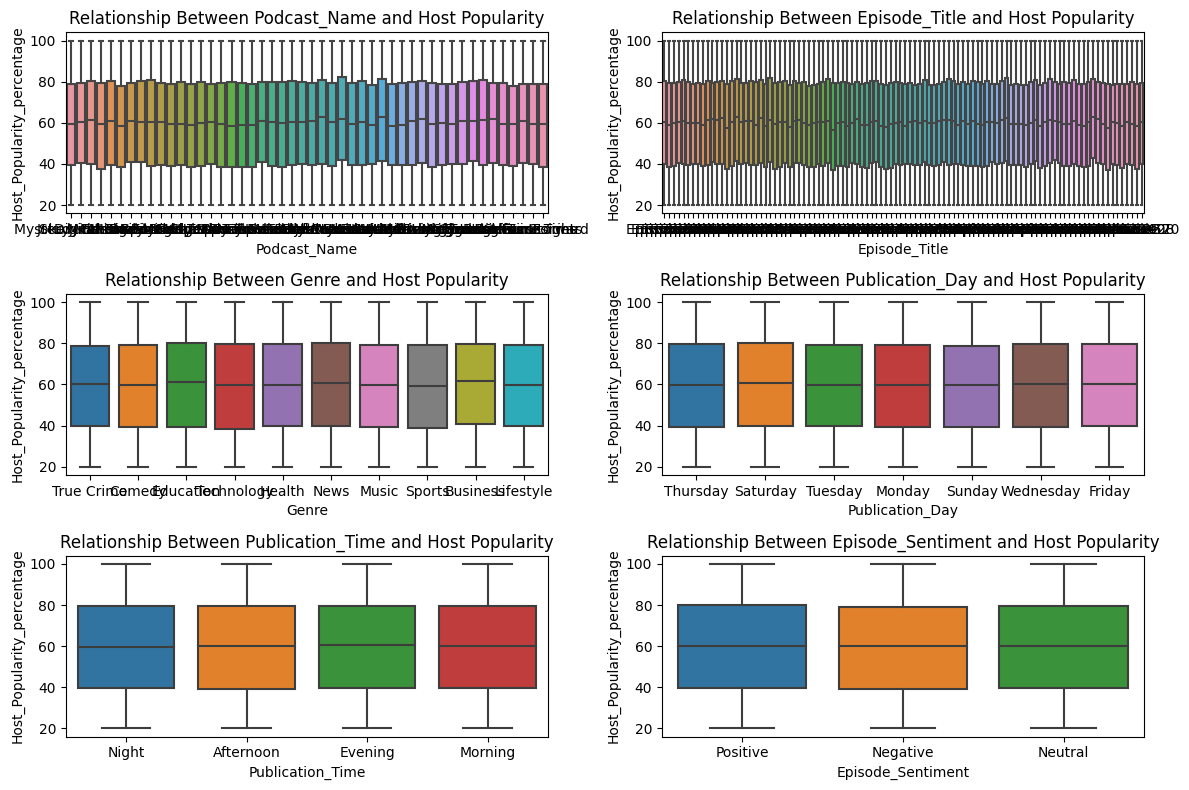

In [19]:
# relationship between cateogircal features and host popularity
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Host_Popularity_percentage"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Host Popularity")

plt.tight_layout()
plt.show()

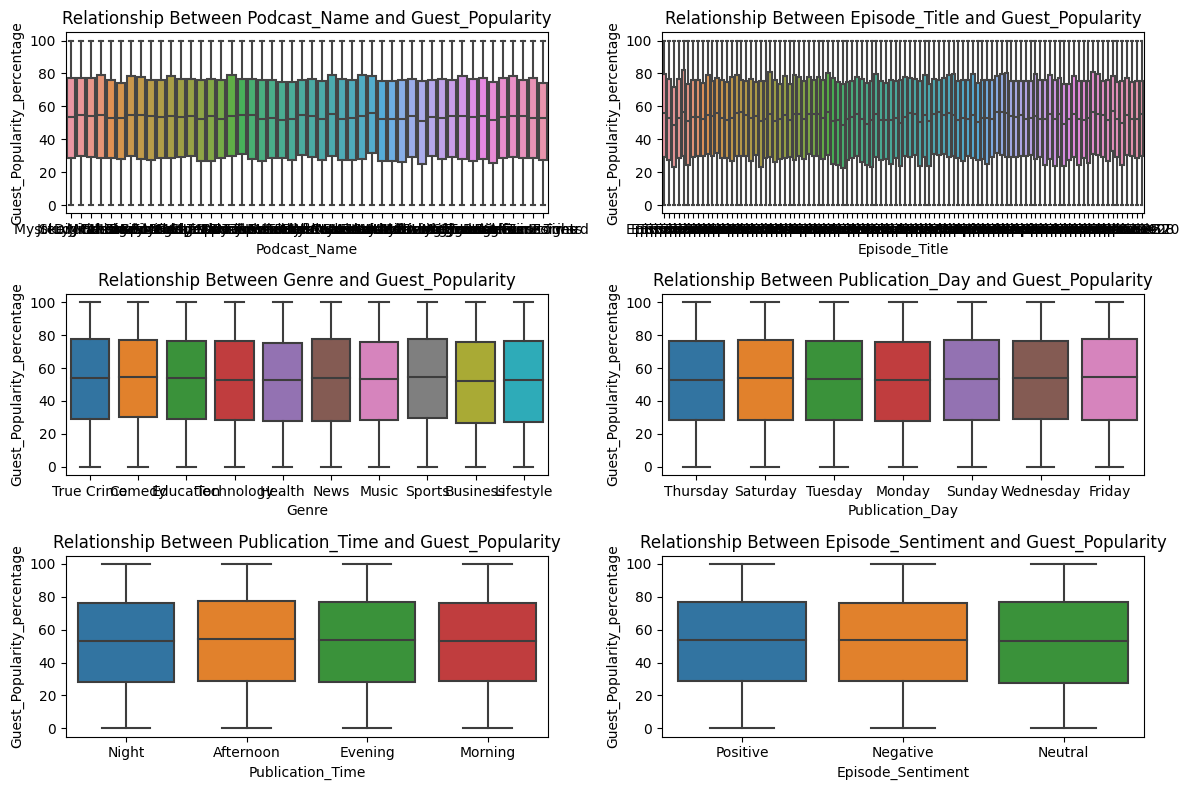

In [20]:
# relationship between cateogircal features and Guest Popularity
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df["Guest_Popularity_percentage"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Guest_Popularity")

plt.tight_layout()
plt.show()

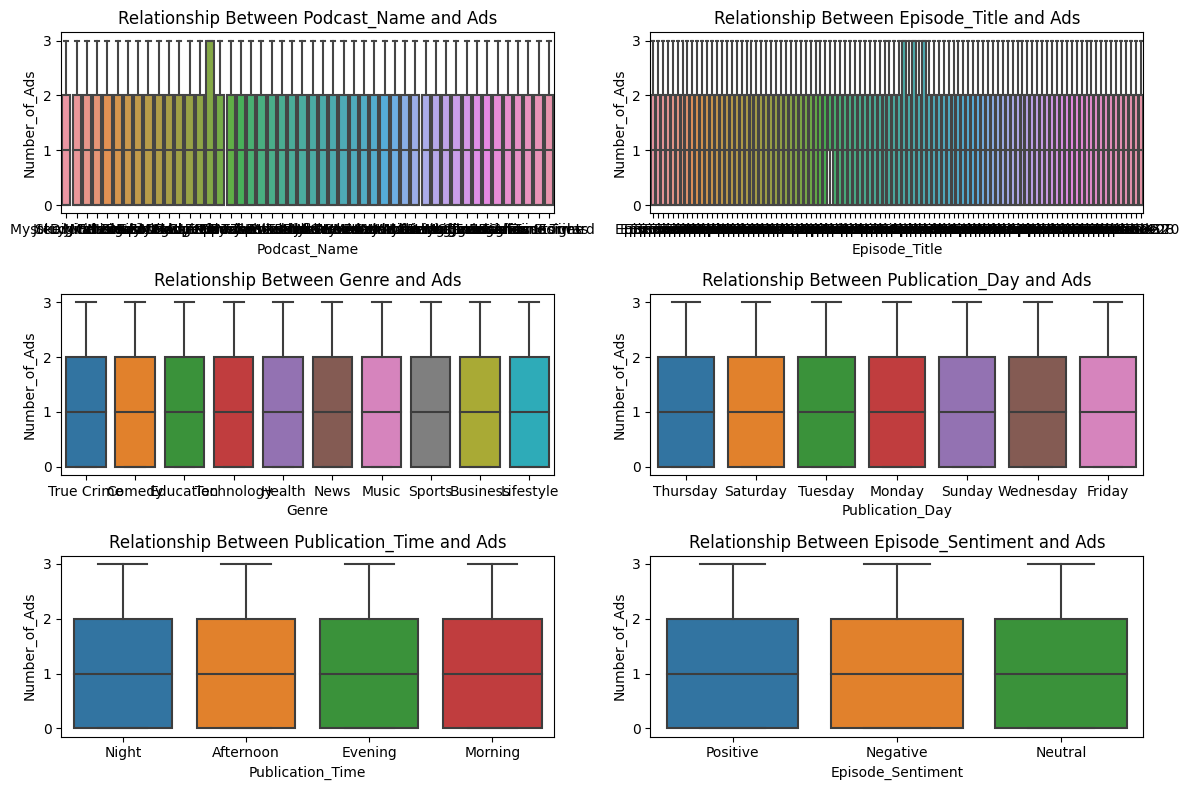

In [21]:
# relationship between cateogircal features and Ads
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(cat_vars):
    sns.boxplot(x=df[feature], y=df[df["Number_of_Ads"]<10]["Number_of_Ads"], ax=axes[i])
    axes[i].set_title(f"Relationship Between {feature} and Ads")

plt.tight_layout()
plt.show()

In [22]:
cat_vars

['Podcast_Name',
 'Episode_Title',
 'Genre',
 'Publication_Day',
 'Publication_Time',
 'Episode_Sentiment']

<Axes: xlabel='Episode_Sentiment', ylabel='Podcast_Name'>

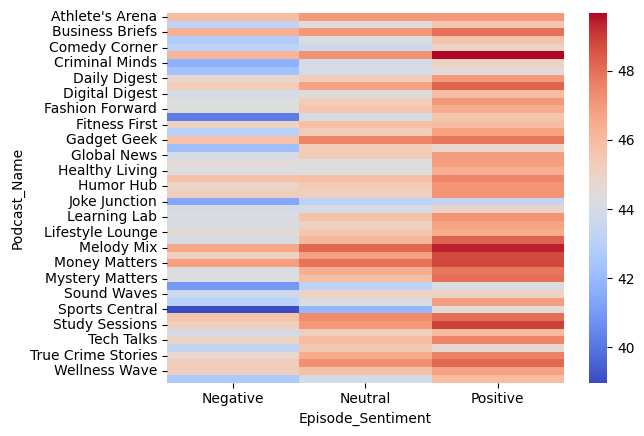

In [23]:
pivot = df.pivot_table(index='Podcast_Name', columns='Episode_Sentiment', values='Listening_Time_minutes', aggfunc='mean')
sns.heatmap(pivot, cmap="coolwarm")

In [24]:
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,662851.000000,749937.000000,603910.000000,749936.000000,749937.000000
mean,64.503523,59.859068,52.234920,1.347938,45.436349
std,32.967924,22.870788,28.449696,1.110975,27.137709
min,0.000000,20.000000,0.000000,0.000000,0.000000
25%,35.730000,39.410000,28.380000,0.000000,23.178350
50%,63.840000,60.050000,53.580000,1.000000,43.379460
75%,94.070000,79.530000,76.600000,2.000000,64.811580
max,120.930000,100.000000,99.990000,3.000000,119.970000


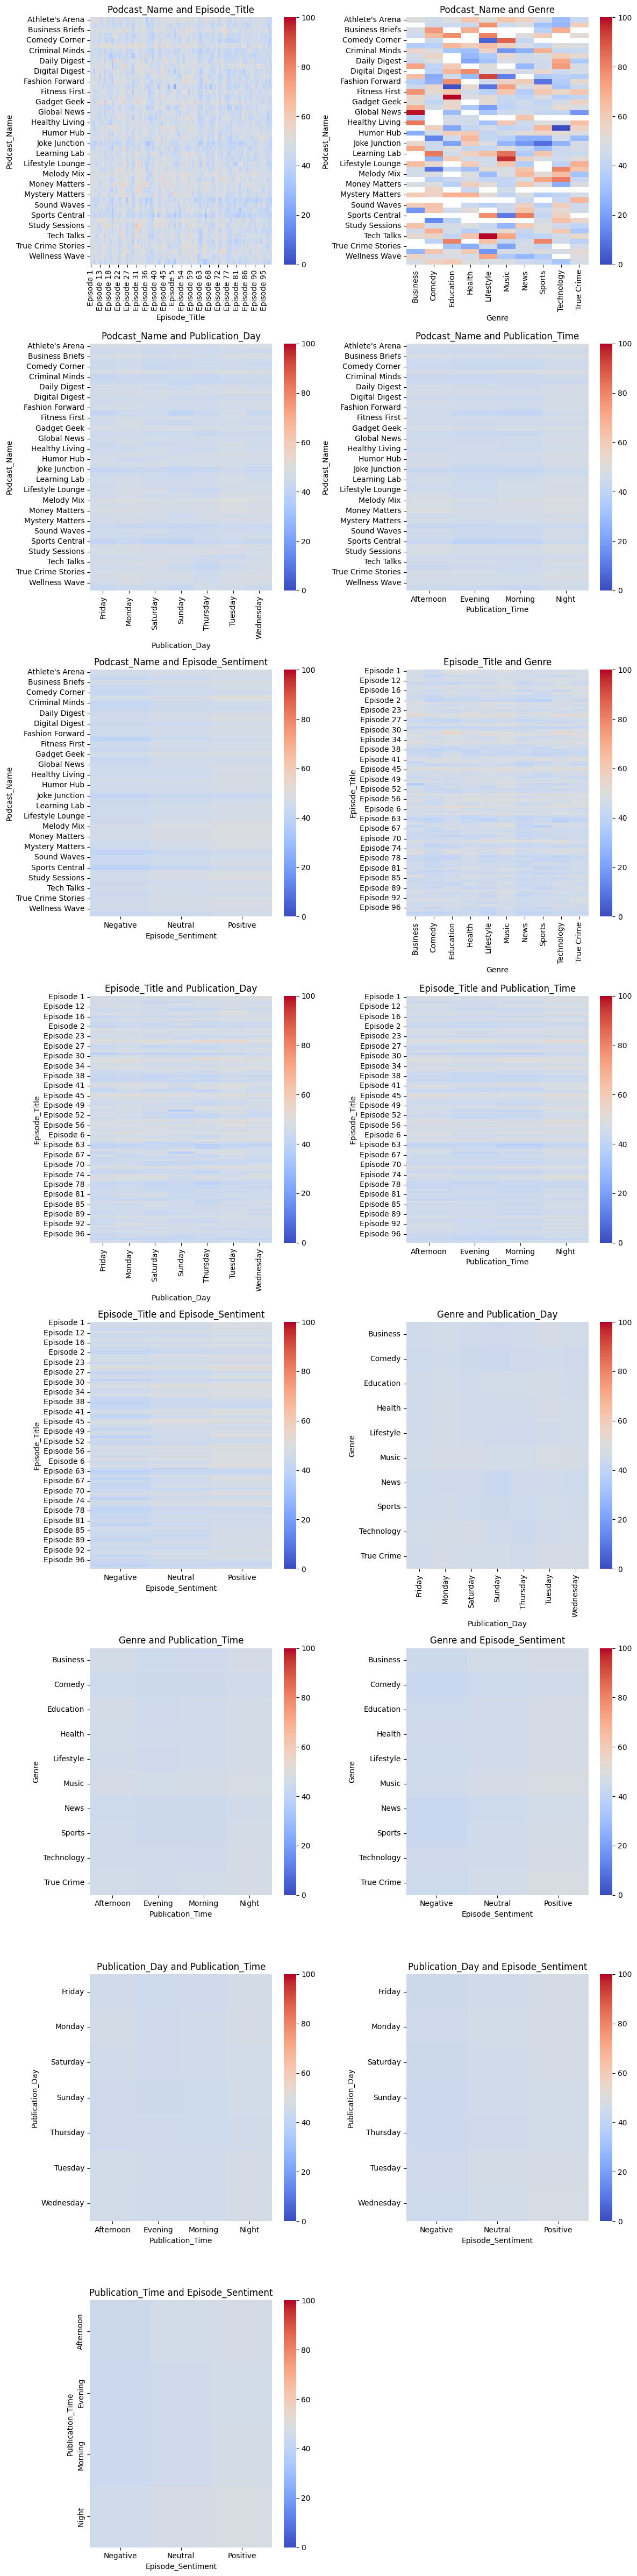

In [25]:
# relationship between two categorical features and outcome
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        pivot = df.pivot_table(index=feature_1, columns=feature_2, values='Listening_Time_minutes', aggfunc='mean')
        sns.heatmap(pivot, cmap="coolwarm", ax=axes[index], vmin=0, vmax=100)
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

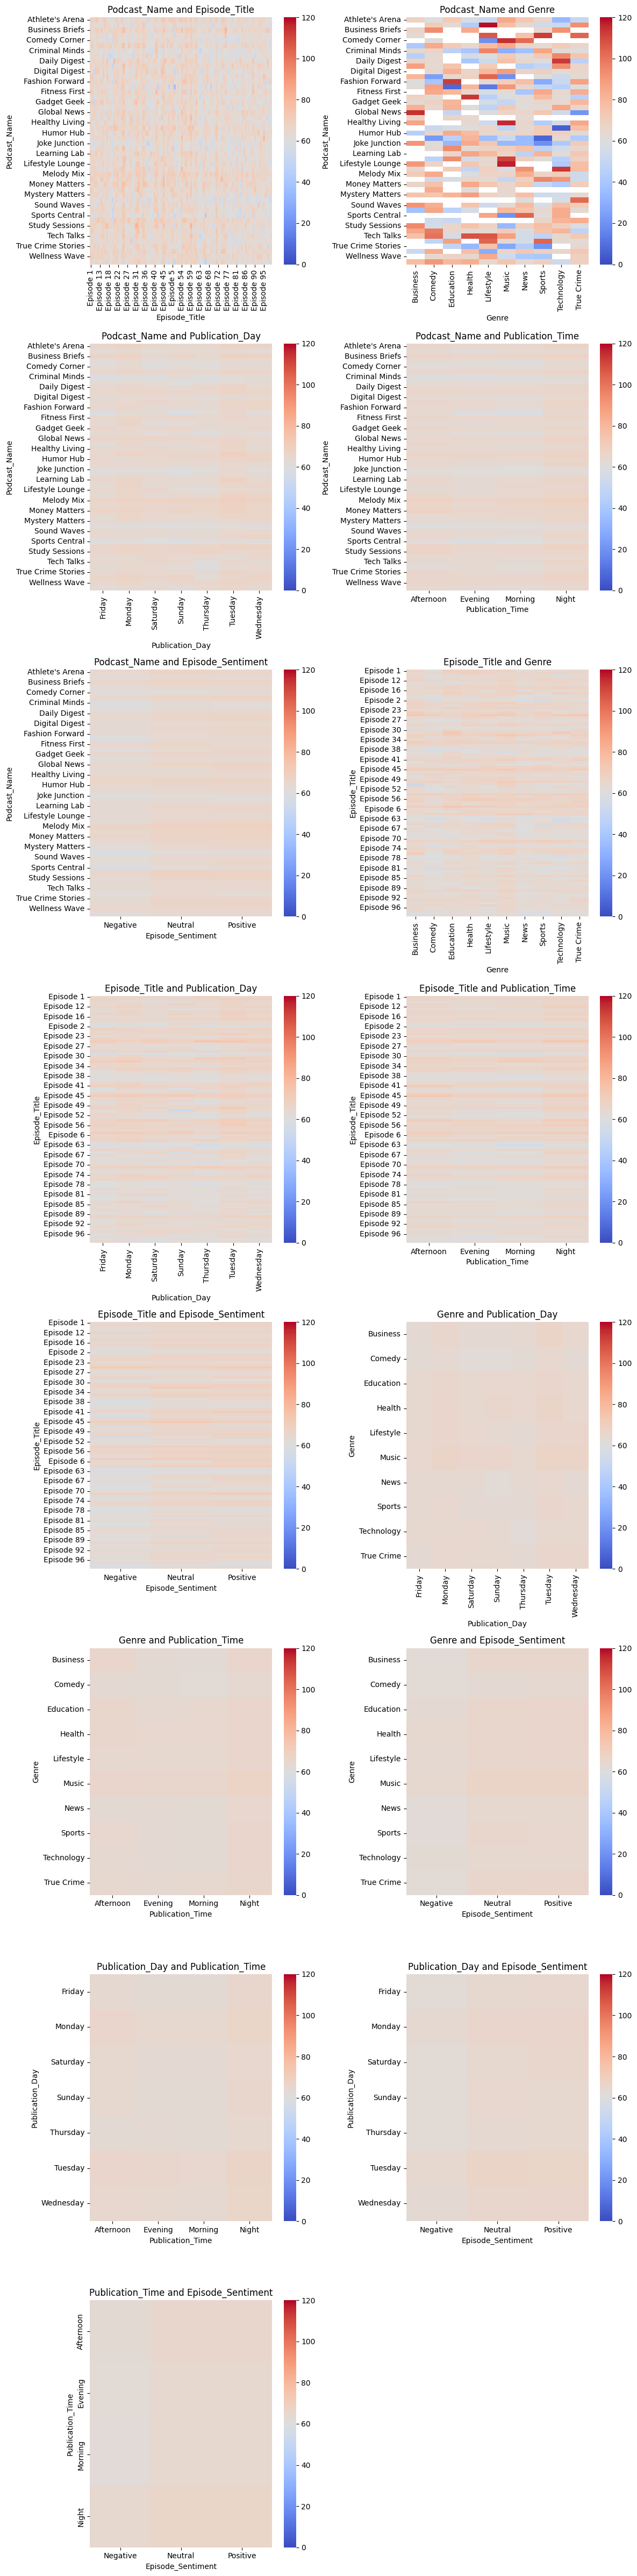

In [26]:
# relationship between two categorical features and episode length
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        pivot = df.pivot_table(index=feature_1, columns=feature_2, values='Episode_Length_minutes', aggfunc='mean')
        sns.heatmap(pivot, cmap="coolwarm", ax=axes[index], vmin=0, vmax=120)
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

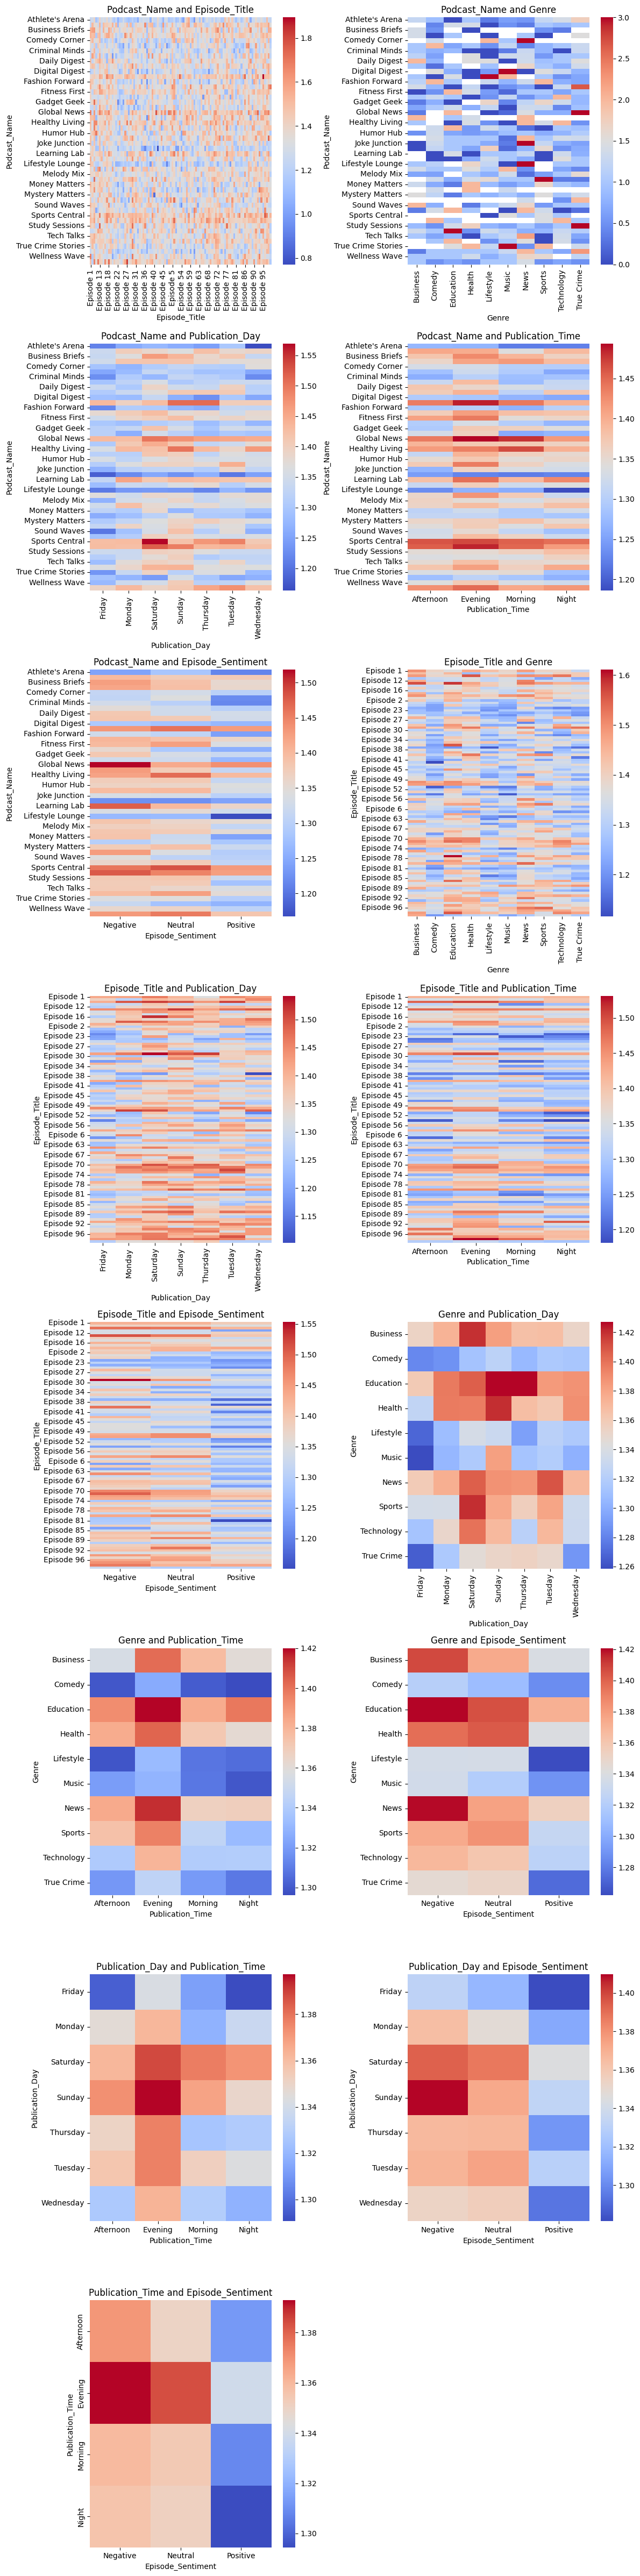

In [27]:
# relationship between two categorical features and num ads
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        pivot = df.pivot_table(index=feature_1, columns=feature_2, values='Number_of_Ads', aggfunc='mean')
        sns.heatmap(pivot, cmap="coolwarm", ax=axes[index])
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

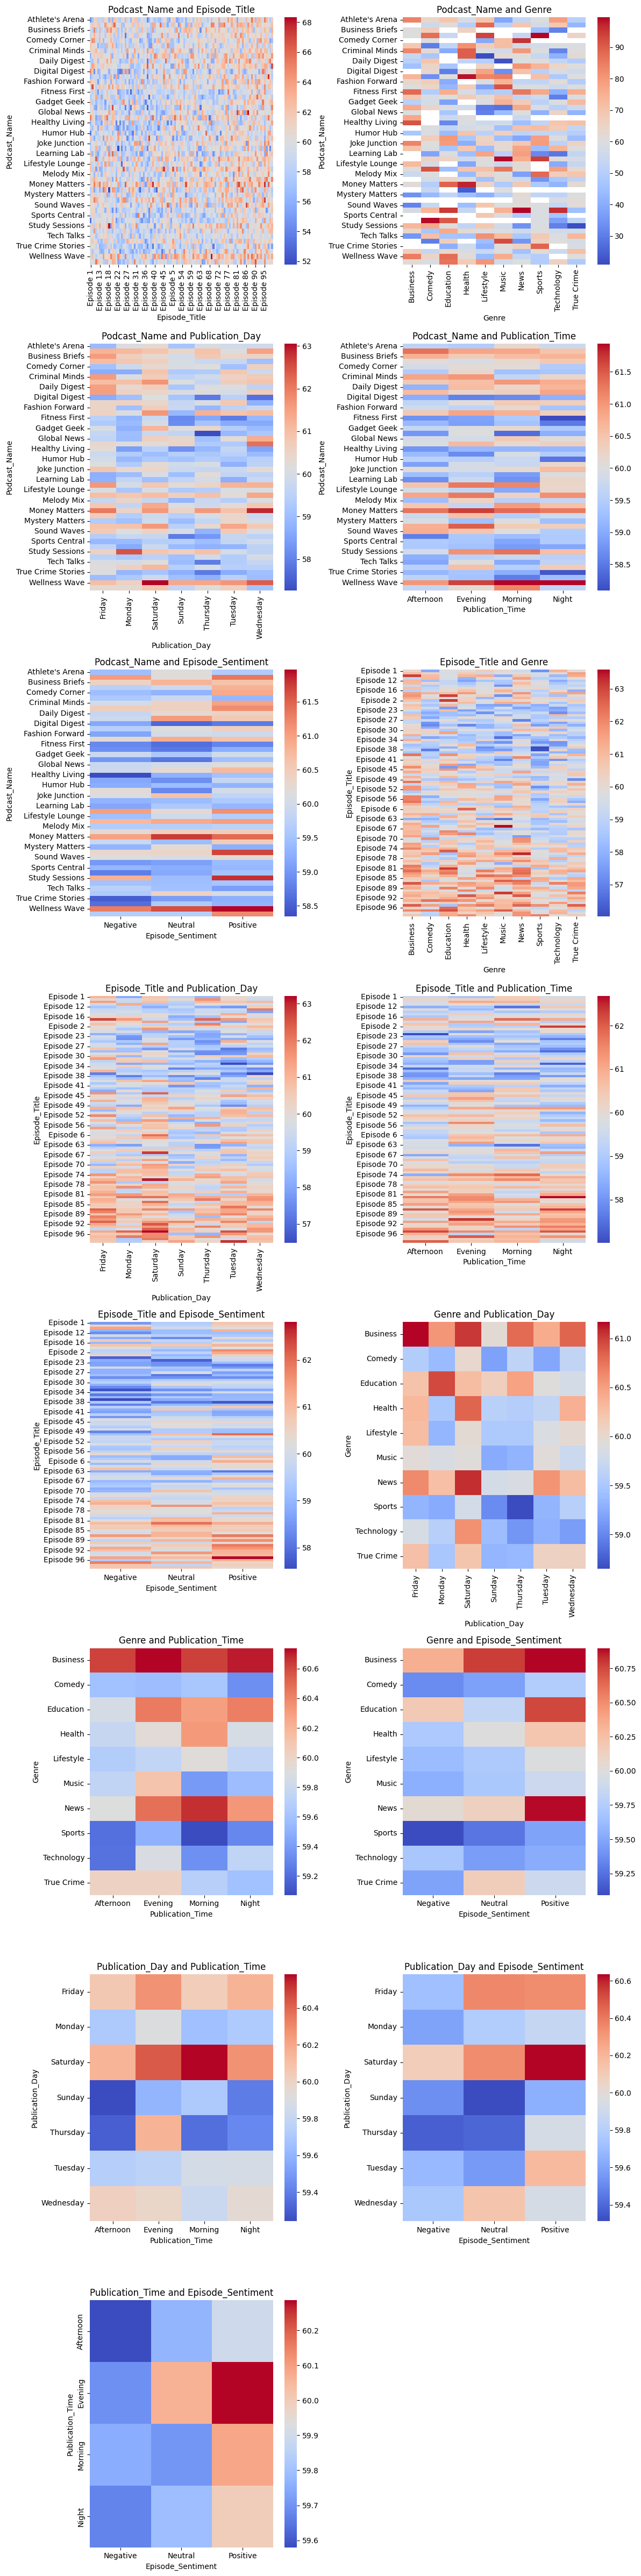

In [28]:
# relationship between two categorical features and host_popularity
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        pivot = df.pivot_table(index=feature_1, columns=feature_2, values='Host_Popularity_percentage', aggfunc='mean')
        sns.heatmap(pivot, cmap="coolwarm", ax=axes[index])
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

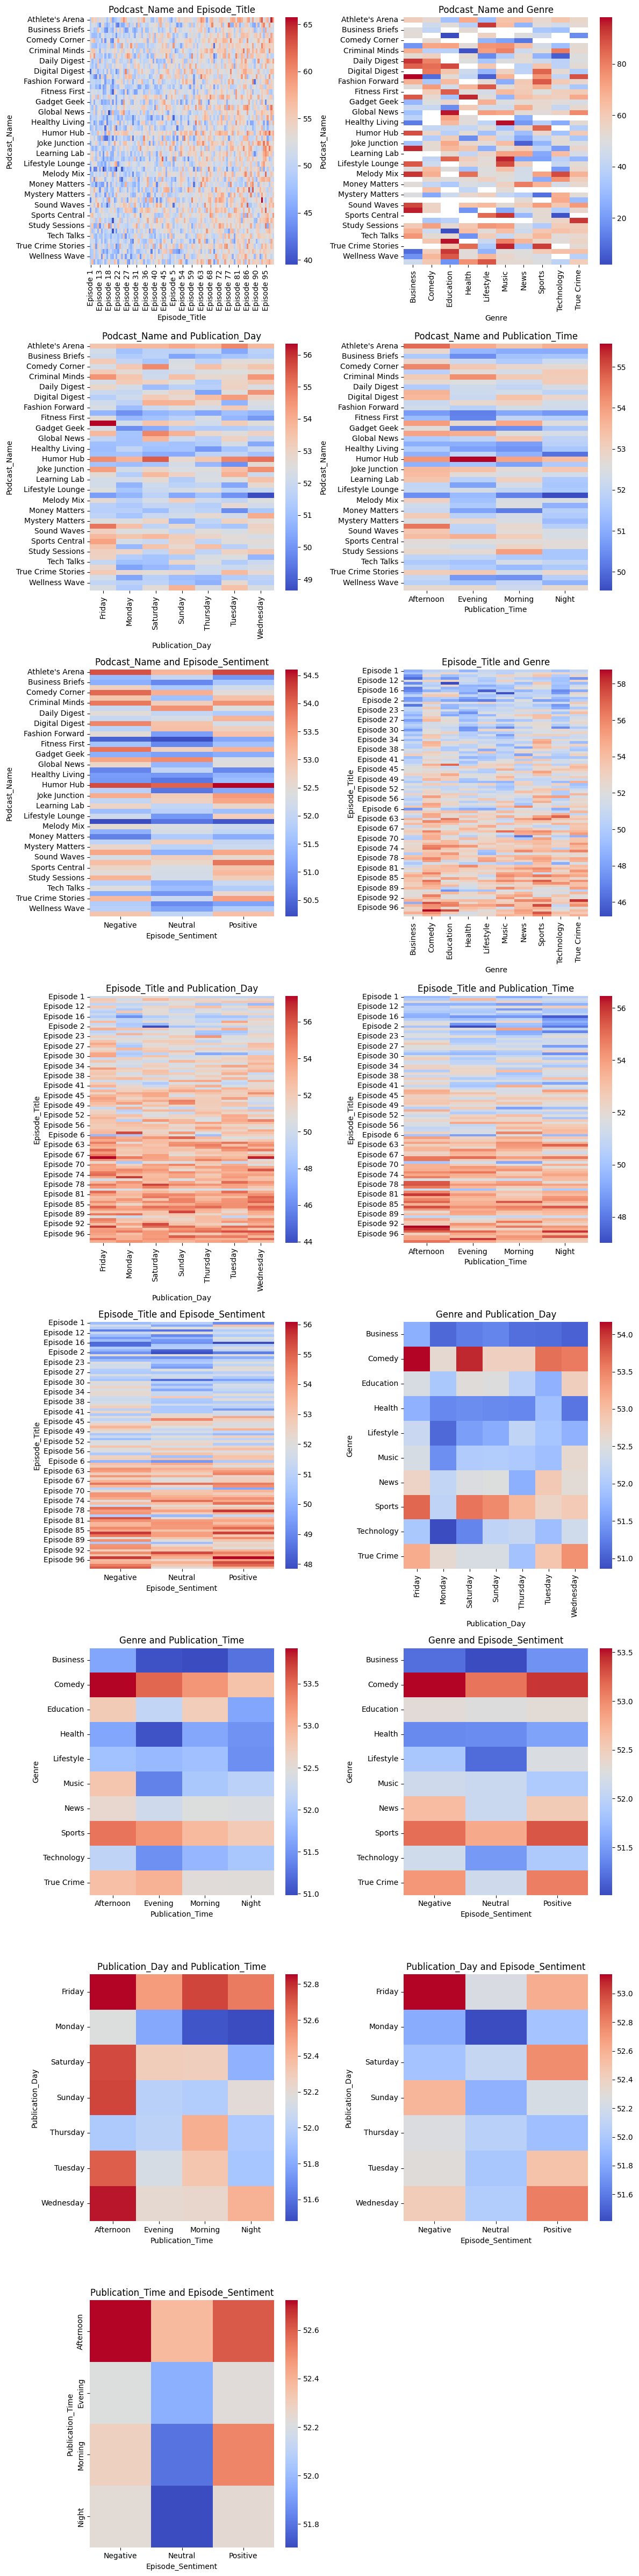

In [29]:
# relationship between two categorical features and Gust Popularity
fig, axes = plt.subplots(8, 2, figsize=(12, 48))
axes = axes.flatten()
index = 0

for i, feature_1 in enumerate(cat_vars):
    for feature_2 in cat_vars[i+1:]:
        if index >= 16:
            break
        pivot = df.pivot_table(index=feature_1, columns=feature_2, values='Guest_Popularity_percentage', aggfunc='mean')
        sns.heatmap(pivot, cmap="coolwarm", ax=axes[index])
        axes[index].set_title(f"{feature_1} and {feature_2}")

        index += 1

axes[15].remove()
plt.tight_layout()
plt.show()

### Findings from Relationships Between Categorical and Numeric Data
- For just about every interaction it seems like the categorical features do not have much to do with the numerical features. This means that the features are largely independent of each other which could be highly benefitial to building a robust model.
- Categorical Features do not have much to do with the outcome feature. This might be problematic as it means that theres not a lot to explain the variation in the outcome variable.